# Modeling — Prévision des Ventes
## Preprocessing → Training → Prédiction

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import warnings
import json
import joblib

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (GradientBoostingRegressor, ExtraTreesRegressor,
                               AdaBoostRegressor)
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement depuis ClickHouse

In [83]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT
    d.Year                               AS year,
    d.Month                              AS month,
    d.Quarter                            AS quarter,
    SUM(f.LinePrice)                     AS total_sales,
    SUM(f.Quantity)                      AS total_quantity,
    COUNT(DISTINCT f.DocumentCode)       AS nb_documents,
    COUNT(DISTINCT f.ClientSK)           AS nb_clients,
    COUNT(DISTINCT f.ItemSK)             AS nb_produits,
    COUNT(DISTINCT f.GeographicalAreaSK) AS nb_regions,
    COUNT(DISTINCT f.WarehouseSK)        AS nb_warehouses,
    AVG(f.DiscountPercentage)            AS avg_discount,
    SUM(f.DiscountAmount)                AS total_discount,
    SUM(f.CostPrice)                     AS total_cost,
    SUM(f.LinePrice - f.CostPrice)       AS total_marge
FROM gold.fact_sales AS f
JOIN gold.dim_date AS d ON f.DateSK = d.DateSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month, quarter
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print(f'✅ {len(df)} mois chargés')
df.head()

✅ 51 mois chargés


,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,nb_produits,nb_regions,nb_warehouses,avg_discount,total_discount,total_cost,total_marge,date
0,2021,3,1,404.06,6,1,1,6,1,2,15.00,60.61,334.97,69.09,2021-03-01
1,2022,1,1,"591,407.94",10983,1125,197,3225,9,3,9.28,"44,802.24","604,390.30","-12,982.36",2022-01-01
2,2022,2,1,"576,097.45",10770,1263,190,3327,9,3,9.69,"36,225.76","677,038.55","-100,941.11",2022-02-01
3,2022,3,1,"680,213.89",11488,1304,200,3497,9,3,7.93,"40,184.68","683,998.33","-3,784.44",2022-03-01
4,2022,4,2,"650,789.55",11385,1093,224,3264,9,4,9.09,"47,939.71","638,230.20","12,559.36",2022-04-01


## 2. Nettoyage — Suppression des mois incomplets

In [84]:
print(f'Avant nettoyage : {len(df)} mois')
print('Mois incomplets :')
print(df[
    (df['date'] < '2022-01-01') | (df['date'] >= '2026-02-01')
][['date', 'total_sales']].to_string(index=False))

df = df[
    (df['date'] >= '2022-01-01') & (df['date'] < '2026-02-01')
].reset_index(drop=True)

print(f'\nAprès nettoyage : {len(df)} mois')
print(f'Période : {df["date"].min().strftime("%b %Y")} → {df["date"].max().strftime("%b %Y")}')

Avant nettoyage : 51 mois
Mois incomplets :
      date  total_sales
2021-03-01       404.06
2026-02-01   114,247.11

Après nettoyage : 49 mois
Période : Jan 2022 → Jan 2026


## 3. Feature Engineering

In [85]:
# Variables directement disponibles + feature engineering
df_ml = df[[
    'date', 'year', 'month', 'quarter',
    'total_sales',
    'total_quantity', 'nb_documents', 'nb_clients',
]].copy()

# Variables temporelles
df_ml['semester']    = df_ml['month'].apply(lambda x: 1 if x <= 6 else 2)
df_ml['is_summer']   = df_ml['month'].isin([7, 8]).astype(int)
df_ml['is_end_year'] = df_ml['month'].isin([11, 12]).astype(int)
df_ml['is_january']  = (df_ml['month'] == 1).astype(int)

# Lag features
df_ml['lag_1']  = df_ml['total_sales'].shift(1)
df_ml['lag_12'] = df_ml['total_sales'].shift(12)

# lag_12 avec fallback sur moyenne mensuelle (évite de perdre 12 mois)
monthly_avg = df_ml.groupby('month')['total_sales'].mean()
df_ml['lag_12'] = df_ml.apply(
    lambda row: monthly_avg[row['month']] if pd.isna(row['lag_12']) else row['lag_12'],
    axis=1
)

# Rolling features
df_ml['rolling_mean_3'] = df_ml['total_sales'].shift(1).rolling(3).mean()

# Supprimer NaN
df_ml = df_ml.dropna().reset_index(drop=True)

print(f'✅ Dataset prêt : {df_ml.shape}')
print(f'Période : {df_ml["date"].min().strftime("%b %Y")} → {df_ml["date"].max().strftime("%b %Y")}')
df_ml.head()

✅ Dataset prêt : (46, 15)
Période : Apr 2022 → Jan 2026


,date,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,semester,is_summer,is_end_year,is_january,lag_1,lag_12,rolling_mean_3
0,2022-04-01,2022,4,2,"650,789.55",11385,1093,224,1,0,0,0,"680,213.89","988,770.24","615,906.42"
1,2022-05-01,2022,5,2,"734,335.68",14813,1199,220,1,0,0,0,"650,789.55","1,148,927.19","635,700.29"
2,2022-06-01,2022,6,2,"754,273.83",12461,1280,223,1,0,0,0,"734,335.68","1,137,109.13","688,446.37"
3,2022-07-01,2022,7,3,"787,031.57",14561,1112,218,2,1,0,0,"754,273.83","1,276,582.07","713,133.02"
4,2022-08-01,2022,8,3,"847,028.15",14118,1169,213,2,1,0,0,"787,031.57","1,189,156.28","758,547.03"


## 4. Corrélation des variables avec total_sales

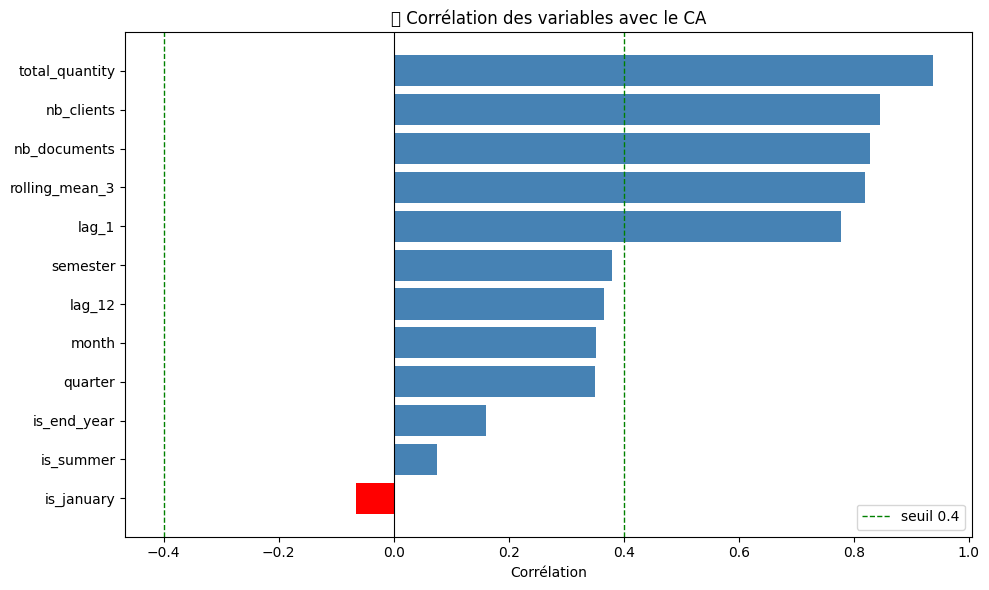


Corrélations :
is_january       -0.07
is_summer         0.08
is_end_year       0.16
quarter           0.35
month             0.35
lag_12            0.37
semester          0.38
lag_1             0.78
rolling_mean_3    0.82
nb_documents      0.83
nb_clients        0.84
total_quantity    0.94

✅ Features finales (12) : ['month', 'quarter', 'semester', 'total_quantity', 'nb_documents', 'nb_clients', 'is_summer', 'is_end_year', 'is_january', 'lag_1', 'lag_12', 'rolling_mean_3']
   Contemporaines incluses : ['nb_clients', 'nb_documents', 'total_quantity']


In [86]:
TARGET = 'total_sales'
FEATURES = [
    'month', 'quarter', 'semester',
    'total_quantity', 'nb_documents', 'nb_clients',
    'is_summer', 'is_end_year', 'is_january',
    'lag_1', 'lag_12', 'rolling_mean_3'
]

corr = df_ml[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0,    color='black', linewidth=0.8)
ax.axvline(0.4,  color='green', linewidth=1, linestyle='--', label='seuil 0.4')
ax.axvline(-0.4, color='green', linewidth=1, linestyle='--')
ax.set_title('📊 Corrélation des variables avec le CA')
ax.set_xlabel('Corrélation')
ax.legend()
plt.tight_layout()
plt.show()

print('\nCorrélations :')
print(corr.to_string())

# ── Pas de filtrage — garder toutes les features ──────────────
FEATURES_FINAL = FEATURES

CONTEMPORAINES_IN_FEATURES = [f for f in ['nb_clients', 'nb_documents', 'total_quantity']
                               if f in FEATURES_FINAL]

print(f'\n✅ Features finales ({len(FEATURES_FINAL)}) : {FEATURES_FINAL}')
print(f'   Contemporaines incluses : {CONTEMPORAINES_IN_FEATURES}')

X = df_ml[FEATURES_FINAL]
y = df_ml[TARGET]

## 5. Sélection des features — seuil forcé à 0.4

In [87]:
tscv       = TimeSeriesSplit(n_splits=4)
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results_thresh = []

for thresh in thresholds:
    selected = corr[abs(corr) > thresh].index.tolist()
    if len(selected) < 2:
        continue
    X_all = df_ml[selected]
    y_all = df_ml[TARGET]
    sc    = StandardScaler()
    X_sc  = sc.fit_transform(X_all)
    cv_scores = cross_val_score(
        LinearRegression(), X_sc, y_all,
        cv=tscv, scoring='neg_mean_absolute_error'
    )
    mae_cv = -cv_scores.mean()
    results_thresh.append({
        'threshold':   thresh,
        'nb_features': len(selected),
        'features':    selected,
        'MAE_cv':      mae_cv,
    })
    print(f'threshold={thresh} | nb_features={len(selected):>2} | MAE_cv={mae_cv:>10,.0f} DT')

df_thresh = pd.DataFrame(results_thresh)

# ── Seuil forcé à 0.4 ──────────────────────────────────────────
FORCED_THRESHOLD = 0.3
best_row      = df_thresh[df_thresh['threshold'] == FORCED_THRESHOLD].iloc[0]
FEATURES_FINAL = best_row['features']

print(f'\n🏆 Seuil choisi (forcé) : {FORCED_THRESHOLD}')
print(f'   MAE_cv              : {best_row["MAE_cv"]:,.0f} DT')
print(f'   Features ({len(FEATURES_FINAL)}) : {FEATURES_FINAL}')

# Variables contemporaines dans les features sélectionnées
CONTEMPORAINES_IN_FEATURES = [f for f in ['nb_clients', 'nb_documents', 'total_quantity']
                               if f in FEATURES_FINAL]
print(f'\n   Contemporaines incluses : {CONTEMPORAINES_IN_FEATURES}')

X = df_ml[FEATURES_FINAL]
y = df_ml[TARGET]

threshold=0.1 | nb_features=10 | MAE_cv=   112,805 DT
threshold=0.2 | nb_features= 9 | MAE_cv=   135,752 DT
threshold=0.3 | nb_features= 9 | MAE_cv=   135,752 DT
threshold=0.4 | nb_features= 5 | MAE_cv=    60,750 DT
threshold=0.5 | nb_features= 5 | MAE_cv=    60,750 DT
threshold=0.6 | nb_features= 5 | MAE_cv=    60,750 DT
threshold=0.7 | nb_features= 5 | MAE_cv=    60,750 DT

🏆 Seuil choisi (forcé) : 0.3
   MAE_cv              : 135,752 DT
   Features (9) : ['quarter', 'month', 'lag_12', 'semester', 'lag_1', 'rolling_mean_3', 'nb_documents', 'nb_clients', 'total_quantity']

   Contemporaines incluses : ['nb_clients', 'nb_documents', 'total_quantity']


## 6. Sauvegarde dataset + features

In [88]:
df_ml.to_csv('/app/notebooks/ml_dataset.csv', index=False)

with open('/app/notebooks/selected_features.json', 'w') as f:
    json.dump(list(FEATURES_FINAL), f)

with open('/app/notebooks/selected_features.json', 'r') as f:
    print(f'✅ Features sauvegardées : {f.read()}')
print(f'✅ Dataset sauvegardé    : {df_ml.shape}')

✅ Features sauvegardées : ["quarter", "month", "lag_12", "semester", "lag_1", "rolling_mean_3", "nb_documents", "nb_clients", "total_quantity"]
✅ Dataset sauvegardé    : (46, 15)


## 7. Split temporel Train / Test (85/15)

Train : 41 mois (Apr 2022 → Aug 2025)
Test  : 5 mois (Sep 2025 → Jan 2026)


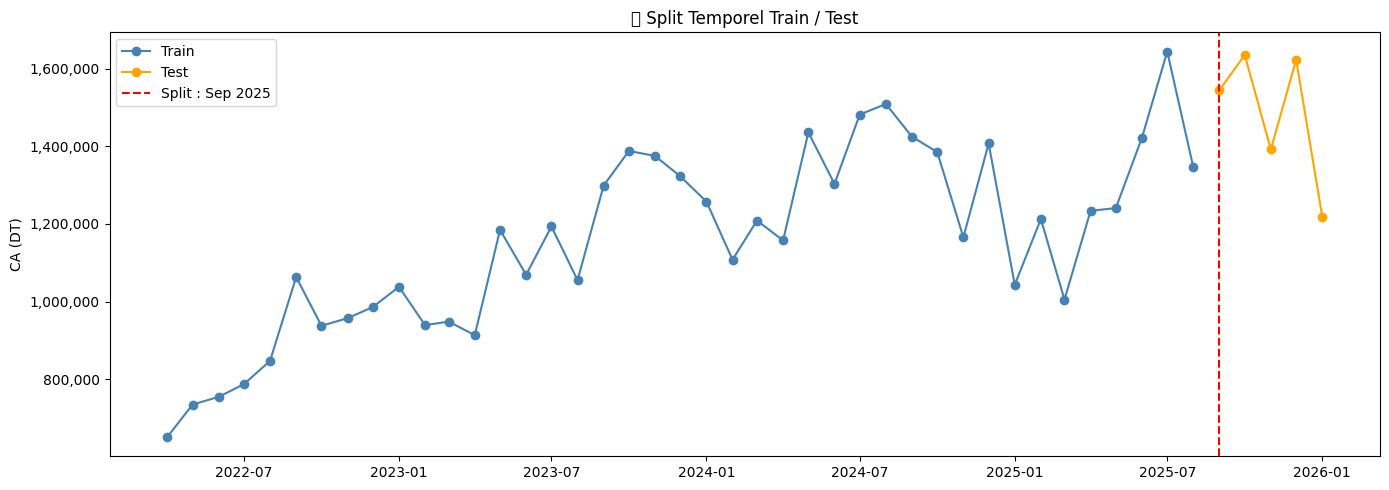

In [89]:
split_idx = int(len(df_ml) * 0.9)
split_date = df_ml.iloc[split_idx]['date']

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
df_train = df_ml.iloc[:split_idx]
df_test  = df_ml.iloc[split_idx:]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train)} mois ({df_train["date"].min().strftime("%b %Y")} → {df_train["date"].max().strftime("%b %Y")})')
print(f'Test  : {len(X_test)} mois ({df_test["date"].min().strftime("%b %Y")} → {df_test["date"].max().strftime("%b %Y")})')

fig, ax = plt.subplots()
ax.plot(df_train['date'], y_train, label='Train', color='steelblue', marker='o')
ax.plot(df_test['date'],  y_test,  label='Test',  color='orange',    marker='o')
ax.axvline(split_date, color='red', linestyle='--', label=f'Split : {split_date.strftime("%b %Y")}')
ax.set_title('📊 Split Temporel Train / Test')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 8. Comparaison des modèles

In [90]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    mae   = mean_absolute_error(y_te, pred)
    rmse  = np.sqrt(mean_squared_error(y_te, pred))
    r2    = r2_score(y_te, pred)
    mape  = np.mean(np.abs((y_te - pred) / y_te)) * 100
    smape = np.mean(2 * np.abs(y_te - pred) /
                   (np.abs(y_te) + np.abs(pred))) * 100
    bias  = np.mean(pred - y_te)
    return {
        'name': name, 'model': model, 'pred': pred,
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'MAPE': mape, 'SMAPE': smape, 'Biais': bias
    }

models_config = [
    # ── Linéaires ─────────────────────────────────────────────
    ('LinearRegression', LinearRegression(),                    X_train_sc, X_test_sc),
   # ('Ridge',            Ridge(alpha=10),                       X_train_sc, X_test_sc),
    #('Lasso',            Lasso(alpha=10),                       X_train_sc, X_test_sc),
   # ('HuberRegressor',   HuberRegressor(),                      X_train_sc, X_test_sc),

    # ── Bagging ───────────────────────────────────────────────
    ('RandomForest',     RandomForestRegressor(
                            n_estimators=100, max_depth=5,
                            random_state=42),                   X_train,    X_test),
    ('ExtraTrees',       ExtraTreesRegressor(
                            n_estimators=100, max_depth=5,
                            random_state=42),                   X_train,    X_test),

    # ── Boosting ──────────────────────────────────────────────
    ('GBT',              GradientBoostingRegressor(
                            n_estimators=400, max_depth=3,
                            learning_rate=0.03,
                            random_state=42),                   X_train,    X_test),
    ('XGBoost',          XGBRegressor(
                            n_estimators=400, max_depth=3,
                            learning_rate=0.03,
                            random_state=42),                   X_train,    X_test),
]


results = []
for name, model, Xtr, Xte in models_config:
    r = evaluate(name, model, Xtr, y_train, Xte, y_test)
    results.append(r)

df_results = pd.DataFrame(results).set_index('name')

print('=' * 85)
print(f'{"Modèle":<20} {"MAE":>10} {"RMSE":>10} {"R²":>8} {"MAPE":>8} {"SMAPE":>8} {"Biais":>12}')
print('=' * 85)
for _, row in df_results.iterrows():
    print(f'{row.name:<20} {row["MAE"]:>10,.0f} {row["RMSE"]:>10,.0f} '
          f'{row["R²"]:>8.4f} {row["MAPE"]:>7.2f}% {row["SMAPE"]:>7.2f}% {row["Biais"]:>12,.0f}')
print('=' * 85)

best_name = df_results['MAPE'].idxmin()
print(f'\n🏆 Meilleur modèle : {best_name} (MAPE = {df_results.loc[best_name, "MAPE"]:.2f}%)')

Modèle                      MAE       RMSE       R²     MAPE    SMAPE        Biais
LinearRegression         62,785     79,855   0.7450    4.57%    4.45%       29,350
RandomForest             69,137     76,166   0.7681    4.62%    4.68%      -39,642
ExtraTrees               48,680     52,889   0.8882    3.38%    3.35%        3,649
GBT                      39,596     45,033   0.9189    2.77%    2.75%        4,285
XGBoost                  33,004     34,667   0.9519    2.25%    2.24%       -3,556

🏆 Meilleur modèle : XGBoost (MAPE = 2.25%)


In [91]:
mape_xgb = df_results.loc['XGBoost', 'MAPE']

pred_train = df_results.loc['XGBoost', 'model'].predict(X_train)

r2_train   = r2_score(y_train, pred_train)
r2_test    = df_results.loc['XGBoost', 'R²']
mape_train = np.mean(np.abs((y_train - pred_train) / y_train)) * 100

print(f'R²   train : {r2_train:.4f}')
print(f'R²   test  : {r2_test:.4f}')
print(f'MAPE train : {mape_train:.2f}%')
print(f'MAPE test  : {mape_xgb:.2f}%')
print(f'\nDifférence R²   : {r2_train - r2_test:.4f}')
print(f'Différence MAPE : {mape_train - mape_xgb:.2f}%')

if r2_train - r2_test > 0.1:
    print('\n⚠️  OVERFITTING détecté !')
else:
    print('\n✅ Pas d\'overfitting significatif')

R²   train : 0.9999
R²   test  : 0.9519
MAPE train : 0.17%
MAPE test  : 2.25%

Différence R²   : 0.0479
Différence MAPE : -2.07%

✅ Pas d'overfitting significatif


## 9. Visualisation CA Réel vs Prédit — tous les modèles

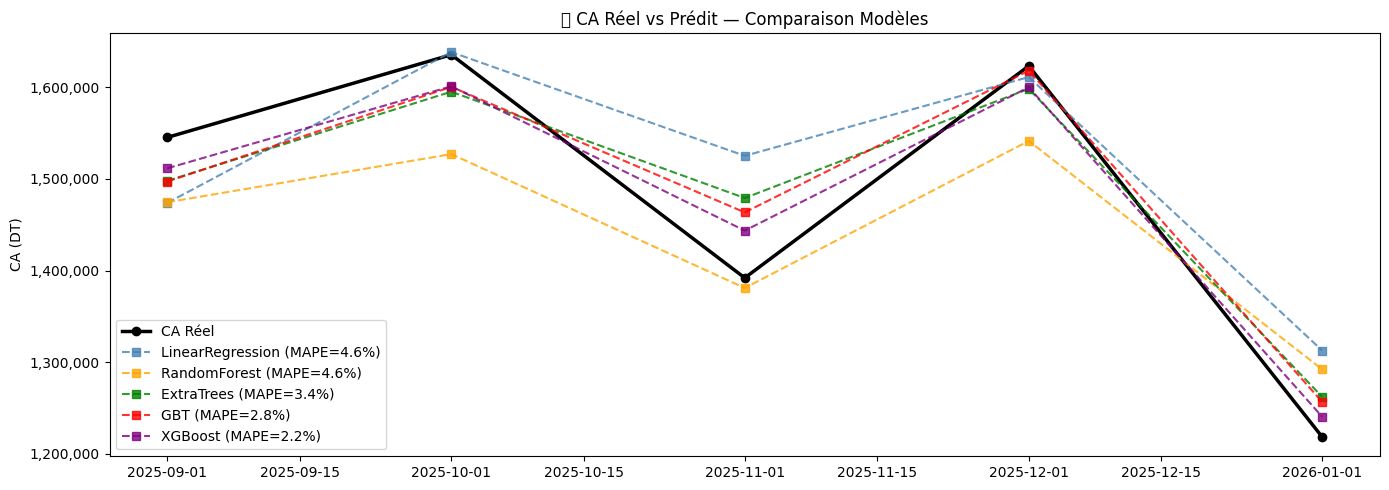

In [92]:
fig, ax = plt.subplots()

ax.plot(df_test['date'], y_test.values,
        label='CA Réel', color='black', marker='o', linewidth=2.5)

colors = ['steelblue', 'orange', 'green', 'red', 'purple']
for (_, row), color in zip(df_results.iterrows(), colors):
    ax.plot(df_test['date'], row['pred'],
            label=f"{row.name} (MAPE={row['MAPE']:.1f}%)",
            marker='s', linestyle='--', color=color, alpha=0.8)

ax.set_title('📈 CA Réel vs Prédit — Comparaison Modèles')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 10. Détail mois par mois — meilleur modèle

In [93]:
best = df_results.loc[best_name]

df_detail = df_test[['date']].copy()
df_detail['reel']   = y_test.values
df_detail['predit'] = best['pred']
df_detail['ecart']  = best['pred'] - y_test.values
df_detail['ecart%'] = (df_detail['ecart'] / df_detail['reel'] * 100).round(2)

print(f'=== Détail {best_name} ===\n')
print(df_detail.to_string(index=False))
print(f"\nBiais : {best['Biais']:,.2f} DT  ({'surestimation' if best['Biais'] > 0 else 'sous-estimation'})")

=== Détail XGBoost ===

      date         reel       predit      ecart  ecart%
2025-09-01 1,545,185.37 1,511,497.25 -33,688.12   -2.18
2025-10-01 1,635,378.39 1,600,921.50 -34,456.89   -2.11
2025-11-01 1,391,948.18 1,443,523.25  51,575.07    3.71
2025-12-01 1,623,158.26 1,599,902.12 -23,256.14   -1.43
2026-01-01 1,218,358.52 1,240,402.88  22,044.35    1.81

Biais : -3,556.34 DT  (sous-estimation)


## 11. Réentraîner sur tout le dataset + Sauvegarde complète

In [94]:
print(f'Réentraînement sur {len(df_ml)} mois complets...')

best_model_obj = df_results.loc[best_name, 'model']
use_scaler     = best_name in ['LinearRegression', 'Ridge']
scaler_final   = StandardScaler()

if use_scaler:
    X_full_sc   = scaler_final.fit_transform(X)
    model_final = type(best_model_obj)(**best_model_obj.get_params())
    model_final.fit(X_full_sc, y)
else:
    model_final = type(best_model_obj)(**best_model_obj.get_params())
    model_final.fit(X, y)
    scaler_final = scaler

# Moyennes des contemporaines pour la prédiction future (6 derniers mois)
contemporaines_means = {}
for col in CONTEMPORAINES_IN_FEATURES:
    contemporaines_means[col] = float(df_ml[col].tail(6).mean())

# Sauvegarder
joblib.dump(model_final,  '/app/notebooks/best_model.pkl')
joblib.dump(scaler_final, '/app/notebooks/scaler.pkl')

config = {
    'best_model':           best_name,
    'use_scaler':           use_scaler,
    'features_final':       list(FEATURES_FINAL),
    'contemporaines':       CONTEMPORAINES_IN_FEATURES,
    'contemporaines_means': contemporaines_means,
    'mape_test':            float(best['MAPE']),
    'mae_test':             float(best['MAE']),
    'r2_test':              float(best['R²']),
    'biais_test':           float(best['Biais']),
}

with open('/app/notebooks/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'✅ Modèle final sauvegardé : {best_name}')
print(f'   Entraîné sur         : {len(df_ml)} mois')
print(f'   MAPE test           : {best["MAPE"]:.2f}%')
print(f'   MAE test            : {best["MAE"]:,.0f} DT')
print(f'   R² test             : {best["R²"]:.4f}')
print(f'   Biais test          : {best["Biais"]:,.0f} DT')
print(f'\n   Moyennes contemporaines (6 derniers mois) :')
for k, v in contemporaines_means.items():
    print(f'     {k:<20} : {v:,.2f}')

Réentraînement sur 46 mois complets...
✅ Modèle final sauvegardé : XGBoost
   Entraîné sur         : 46 mois
   MAPE test           : 2.25%
   MAE test            : 33,004 DT
   R² test             : 0.9519
   Biais test          : -3,556 DT

   Moyennes contemporaines (6 derniers mois) :
     nb_clients           : 321.83
     nb_documents         : 1,600.83
     total_quantity       : 30,238.50


## 12. Prédiction des 12 prochains mois

In [95]:
import plotly.graph_objects as go

# Charger config
with open('/app/notebooks/model_config.json') as f:
    cfg = json.load(f)

FEATURES_FINAL_P       = cfg['features_final']
CONTEMPORAINES_P       = cfg['contemporaines']
CONTEMPORAINES_MEANS_P = cfg['contemporaines_means']
USE_SCALER_P           = cfg['use_scaler']

df_future = df_ml.copy()
last_date = df_future['date'].max()
all_sales = list(df_future['total_sales'])

print(f'Départ   : {last_date.strftime("%b %Y")}')
print(f'Objectif : prédire jusqu\'à {(last_date + pd.DateOffset(months=12)).strftime("%b %Y")}\n')

predictions = []

for i in range(1, 13):
    next_date  = last_date + pd.DateOffset(months=i)
    next_month = next_date.month
    next_year  = next_date.year

    row = {}

    # ── Features temporelles ──────────────────────────────
    if 'year'        in FEATURES_FINAL_P: row['year']        = next_year
    if 'month'       in FEATURES_FINAL_P: row['month']       = next_month
    if 'quarter'     in FEATURES_FINAL_P: row['quarter']     = (next_month - 1) // 3 + 1
    if 'semester'    in FEATURES_FINAL_P: row['semester']    = 1 if next_month <= 6 else 2
    if 'is_summer'   in FEATURES_FINAL_P: row['is_summer']   = 1 if next_month in [7, 8] else 0
    if 'is_end_year' in FEATURES_FINAL_P: row['is_end_year'] = 1 if next_month in [11, 12] else 0
    if 'is_january'  in FEATURES_FINAL_P: row['is_january']  = 1 if next_month == 1 else 0

    # ── Lag features ─────────────────────────────────────
    if 'lag_1'  in FEATURES_FINAL_P: row['lag_1']  = all_sales[-1]
    if 'lag_2'  in FEATURES_FINAL_P: row['lag_2']  = all_sales[-2] if len(all_sales) >= 2 else all_sales[-1]
    if 'lag_3'  in FEATURES_FINAL_P: row['lag_3']  = all_sales[-3] if len(all_sales) >= 3 else all_sales[-1]

    # lag_12 → chercher dans all_sales (inclut les prédictions passées)
    if 'lag_12' in FEATURES_FINAL_P:
        if len(all_sales) >= 12:
            row['lag_12'] = all_sales[-12]   # ← 12 valeurs en arrière (réelles ou prédites)
        else:
            past_same = df_future[df_future['month'] == next_month]['total_sales']
            row['lag_12'] = past_same.iloc[-1] if len(past_same) > 0 else np.mean(all_sales)

    # ── Rolling features ──────────────────────────────────
    if 'rolling_mean_3' in FEATURES_FINAL_P: row['rolling_mean_3'] = np.mean(all_sales[-3:])
    if 'rolling_mean_6' in FEATURES_FINAL_P: row['rolling_mean_6'] = np.mean(all_sales[-6:])

    # ── Variables contemporaines — moyenne 6 derniers mois ─
    for col in CONTEMPORAINES_P:
        if col in FEATURES_FINAL_P:
            row[col] = CONTEMPORAINES_MEANS_P[col]

    # ── Prédiction ────────────────────────────────────────
    X_row = pd.DataFrame([row])[FEATURES_FINAL_P]
    if USE_SCALER_P:
        X_row_sc = scaler_final.transform(X_row)
        pred = model_final.predict(X_row_sc)[0]
    else:
        pred = model_final.predict(X_row)[0]

    all_sales.append(pred)   # ← ajoute la prédiction pour les prochains lags
    predictions.append({
        'date':            next_date,
        'year':            next_year,
        'month':           next_month,
        'predicted_sales': pred,
        'is_prediction':   1
    })
    print(f'  {next_date.strftime("%b %Y")} → {pred:>15,.2f} DT')

df_pred = pd.DataFrame(predictions)
print(f'\n✅ {len(df_pred)} mois prédits')
print(f'CA prévisionnel total : {df_pred["predicted_sales"].sum():,.2f} DT')

Départ   : Jan 2026
Objectif : prédire jusqu'à Jan 2027

  Feb 2026 →    1,285,808.38 DT
  Mar 2026 →    1,360,332.88 DT
  Apr 2026 →    1,322,002.62 DT
  May 2026 →    1,424,360.38 DT
  Jun 2026 →    1,459,194.00 DT
  Jul 2026 →    1,517,817.50 DT
  Aug 2026 →    1,508,503.00 DT
  Sep 2026 →    1,509,107.50 DT
  Oct 2026 →    1,508,904.38 DT
  Nov 2026 →    1,505,444.75 DT
  Dec 2026 →    1,507,605.12 DT
  Jan 2027 →    1,291,773.50 DT

✅ 12 mois prédits
CA prévisionnel total : 17,200,854.00 DT


## 13. Visualisation — Réel + Prédit sur un seul graphe

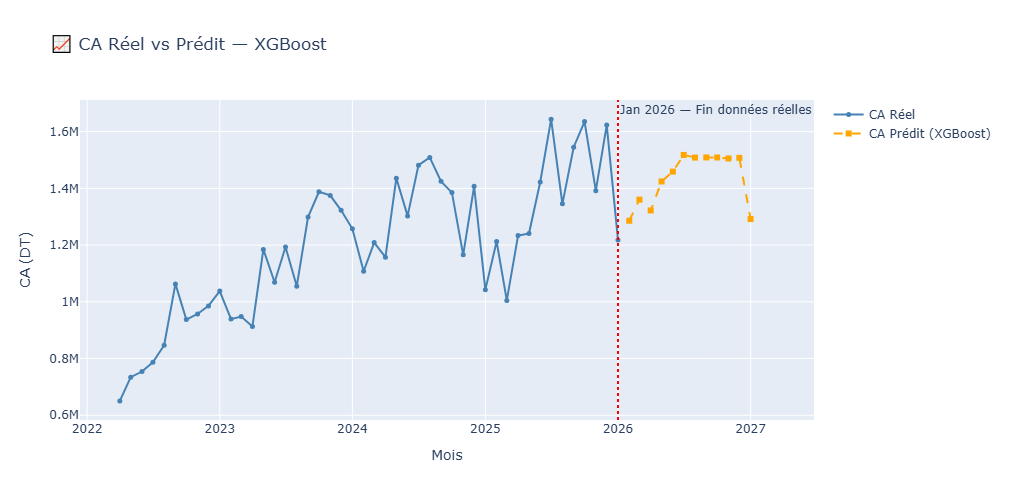

In [96]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_ml['date'], y=df_ml['total_sales'],
    name='CA Réel', mode='lines+markers',
    line=dict(color='steelblue', width=2), marker=dict(size=5)
))

fig.add_trace(go.Scatter(
    x=df_pred['date'], y=df_pred['predicted_sales'],
    name=f'CA Prédit ({best_name})',
    mode='lines+markers',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square')
))

fig.add_vline(
    x=last_date.timestamp() * 1000,
    line_dash='dot', line_color='red',
    annotation_text=f'{last_date.strftime("%b %Y")} — Fin données réelles'
)

fig.update_layout(
    title=f'📈 CA Réel vs Prédit — {best_name}',
    xaxis_title='Mois', yaxis_title='CA (DT)',
    hovermode='x unified', height=500
)
fig.show()

## 14. CA annuel prévu

📋 PRÉVISION CA ANNUEL
CA réel 2024       :   15,843,689.48 DT
CA réel 2025       :   16,342,751.14 DT
CA prévu 2026-2027 :   17,200,854.00 DT
Croissance prévue  :            5.25 %
Modèle             : XGBoost
MAPE test          : 2.25%

Détail mensuel :
      date  predicted_sales
2026-02-01     1,285,808.38
2026-03-01     1,360,332.88
2026-04-01     1,322,002.62
2026-05-01     1,424,360.38
2026-06-01     1,459,194.00
2026-07-01     1,517,817.50
2026-08-01     1,508,503.00
2026-09-01     1,509,107.50
2026-10-01     1,508,904.38
2026-11-01     1,505,444.75
2026-12-01     1,507,605.12
2027-01-01     1,291,773.50


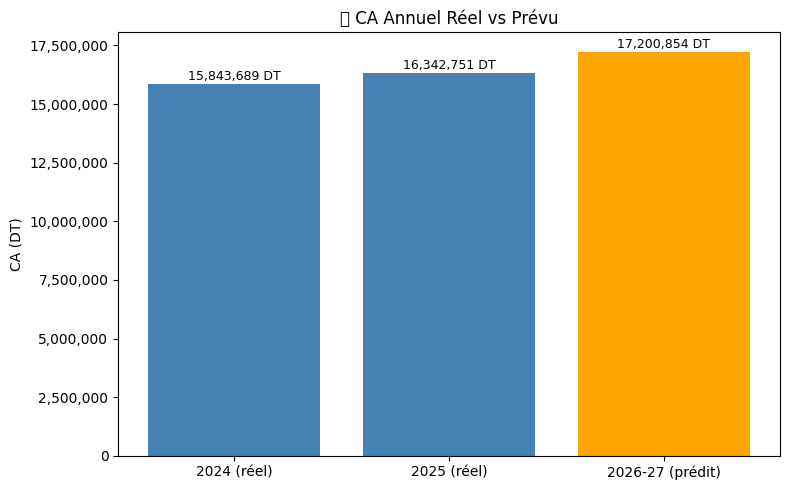

In [97]:
ca_annuel_prevu = df_pred['predicted_sales'].sum()
ca_annuel_2025  = df_ml[df_ml['date'].dt.year == 2025]['total_sales'].sum()
ca_annuel_2024  = df_ml[df_ml['date'].dt.year == 2024]['total_sales'].sum()
croissance      = (ca_annuel_prevu - ca_annuel_2025) / ca_annuel_2025 * 100

print('=' * 55)
print('📋 PRÉVISION CA ANNUEL')
print('=' * 55)
print(f'CA réel 2024       : {ca_annuel_2024:>15,.2f} DT')
print(f'CA réel 2025       : {ca_annuel_2025:>15,.2f} DT')
print(f'CA prévu 2026-2027 : {ca_annuel_prevu:>15,.2f} DT')
print(f'Croissance prévue  : {croissance:>15.2f} %')
print(f'Modèle             : {best_name}')
print(f'MAPE test          : {cfg["mape_test"]:.2f}%')
print('=' * 55)
print('\nDétail mensuel :')
print(df_pred[['date', 'predicted_sales']].to_string(index=False))

# Graphe annuel
years_data = pd.DataFrame([
    {'Année': '2024 (réel)', 'CA': ca_annuel_2024},
    {'Année': '2025 (réel)', 'CA': ca_annuel_2025},
    {'Année': '2026-27 (prédit)', 'CA': ca_annuel_prevu},
])
fig, ax = plt.subplots(figsize=(8, 5))
colors  = ['steelblue', 'steelblue', 'orange']
ax.bar(years_data['Année'], years_data['CA'], color=colors)
for i, (_, r) in enumerate(years_data.iterrows()):
    ax.text(i, r['CA'] + years_data['CA'].max() * 0.01,
            f"{r['CA']:,.0f} DT", ha='center', fontsize=9)
ax.set_title('📊 CA Annuel Réel vs Prévu')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## 15. Écriture dans ClickHouse Gold

In [99]:
client2 = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

client2.command("""
    CREATE TABLE IF NOT EXISTS gold.ml_predictions (
        date             Date,
        year             Int32,
        month            Int32,
        predicted_sales  Float64,
        is_prediction    Int8
    )
    ENGINE = MergeTree()
    ORDER BY date
""")

client2.command('TRUNCATE TABLE gold.ml_predictions')
client2.insert_df('gold.ml_predictions',
    df_pred[['date', 'year', 'month', 'predicted_sales', 'is_prediction']])

check = client2.query_df('SELECT * FROM gold.ml_predictions ORDER BY date')
print(f'✅ {len(check)} prédictions écrites dans ClickHouse Gold')
print('   Table : gold.ml_predictions\n')
print(check.to_string(index=False))

ProgrammingError: Unrecognized column 'date' in table gold.ml_predictions